# El Nino 2026: Seasonal Outlook for Africa
## Using ECMWF SEAS5 via the Copernicus CDS

**Author:** Valters Zeizis, ECMWF
**Context:** Continental Preparedness Framework 2026 El Nino


## What this notebook does

Demonstrates how to use free ECMWF data from the Copernicus Climate Data Store (CDS)
to build a regional seasonal outlook for Africa, directly relevant to the 2026 El Nino
preparedness framework.

**Key question:** What does the current seasonal forecast tell us about precipitation
anomalies across the four SEWA regions for the coming months, and how confident is
that signal?

## Why these data sources?

| Source | What it provides | Role in this notebook |
|---|---|---|
| **SEAS5 forecast** | 51-member ensemble, months 1-6 ahead | The forecast signal |
| **SEAS5 hindcast (re-forecast), 1993-2016** | 25-member ensemble re-run over the past | The model's own climatology: the anomaly baseline |
| **ERA5 reanalysis, 1993-2016** | Observation-based estimate of what actually happened | Observed context and model-bias illustration only |

All three are **free** via [cds.climate.copernicus.eu](https://cds.climate.copernicus.eu).

> **Why anomalies are computed against the hindcast, not ERA5:** SEAS5 has its own
> systematic biases (it may be persistently wetter or drier than reality in a given
> region). Differencing the forecast against the *model's own* 1993-2016 climate
> removes that bias and isolates the forecast signal. Differencing against ERA5 would
> mix model bias into the "anomaly". This follows the standard C3S methodology
> (see the [C3S seasonal anomalies tutorial](https://ecmwf-projects.github.io/copernicus-training-c3s/sf-anomalies.html)).
> Section 5 visualises the bias explicitly.

## The 2026 El Nino context

An El Nino event is developing during 2026: WMO indicated roughly 80% likelihood
of El Nino conditions during June-August 2026, with some forecasts suggesting a
strong event. Quoted index magnitudes are dataset-dependent (ONI uses the
smoother ERSSTv5; ECMWF uses ERA5 SST), so figures from different centres are
not directly comparable, and this notebook makes no claim about eventual event
strength.

> **How event strength is measured:** This notebook shows the *impact* side
> (African rainfall response in SEAS5). For measuring the strength of the event
> itself, ECMWF introduced Relative Nino indices in June 2026 (comparing Nino 3.4
> SST against the whole tropics, reducing sensitivity to background warming),
> now included in the operational SEAS5 Nino plots. See the ECMWF science blog:
> [Measuring the strength of El Nino](https://www.ecmwf.int/en/about/media-centre/science-blog/2026/measuring-strength-el-nino).
> The baseline logic in Section 5 is the same idea applied to precipitation:
> anomalies are only meaningful against the right reference.

Rather than restating expected impacts from the literature, this notebook derives
what the current SEAS5 initialisation actually shows for the four SEWA regions,
and how confident that signal is.

## 1) Setup

In [30]:
import calendar
import cdsapi
import cfgrib
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle
from pathlib import Path
from datetime import datetime, timezone

# Shared helpers (same directory as this notebook)
from add_attribution import save_with_attribution
from _utils import get_data_dir

DATA_DIR = Path(get_data_dir())          # repo-root/data  (gitignored cache)
FIG_DIR  = DATA_DIR.parent / 'figures'   # repo-root/figures (committed, with logos)
FIG_DIR.mkdir(parents=True, exist_ok=True)

c = cdsapi.Client(quiet=True)

# --- Forecast initialisation date -------------------------------------------
# SEAS5 for the current month is published around the 13th; before that, fall
# back to the previous month so the notebook always runs.
now = datetime.now(timezone.utc)
if now.day < 14:
    init = pd.Timestamp(now.year, now.month, 1) - pd.DateOffset(months=1)
else:
    init = pd.Timestamp(now.year, now.month, 1)
FCST_YEAR, FCST_MONTH = str(init.year), f'{init.month:02d}'

HINDCAST_YEARS = list(range(1993, 2017))   # standard SEAS5 re-forecast period
LEADS = [1, 2, 3, 4, 5, 6]                 # leadtime_month values requested

# SEWA focus regions
REGIONS = {
    'Western Africa (AGRHYMET)':  {'lon': [-20, 20], 'lat': [4,  20],  'color': '#F59E0B'},
    'Central Africa (CAPC-AC)':   {'lon': [8,  30],  'lat': [-5, 10],  'color': '#8B5CF6'},
    'Eastern Africa (ICPAC)':     {'lon': [28, 52],  'lat': [-5, 20],  'color': '#3B82F6'},
    'Southern Africa (SADC-CSC)': {'lon': [10, 50],  'lat': [-35, -5], 'color': '#EF4444'},
}

def region_mean(da, reg):
    """Area-weighted mean over a region box (weights = cos latitude).
    Works for any DataArray with latitude/longitude dims; other dims are kept.
    Assumes latitude is sorted ascending (we sort on load)."""
    sub = da.sel(latitude=slice(reg['lat'][0], reg['lat'][1]),
                 longitude=slice(reg['lon'][0], reg['lon'][1]))
    w = np.cos(np.deg2rad(sub.latitude))
    return sub.weighted(w).mean(['latitude', 'longitude'])

print(f'Data cache : {DATA_DIR}')
print(f'Figures to : {FIG_DIR}')
print(f'Forecast initialisation: {FCST_YEAR}-{FCST_MONTH}')


Data cache : /Users/valtze/ecmwf-open-data-guide/data
Figures to : /Users/valtze/ecmwf-open-data-guide/figures
Forecast initialisation: 2026-06


## 2) Fetch SEAS5: Seasonal Precipitation Forecast

**What:** Monthly mean total precipitation for Africa, 51 ensemble members, lead months 1-6.

**Lead time convention (CDS):** `leadtime_month = 1` is the calendar month of the
initialisation itself (a 1 May start gives May as lead month 1). We do not rely on
this convention by hand: valid months are read from the data's `valid_time`
coordinate in Section 4, so panel labels are correct by construction.

**Why 51 members:** Ensemble spread quantifies forecast confidence.
Narrow spread = strong signal. Wide spread = high uncertainty.
Sections 10-12 use the full per-member data to show this explicitly.

> Accept the licence at [cds.climate.copernicus.eu](https://cds.climate.copernicus.eu/datasets/seasonal-monthly-single-levels?tab=download#manage-licences)

> **Note:** New SEAS5 initialisations are published on the CDS around the 13th
> of each month. Before that date this notebook automatically uses the previous
> month's initialisation, so the first lead month may already have passed:
> normal for seasonal forecasting between releases.


In [31]:
seas5_path = DATA_DIR / f'seas5_tp_africa_{FCST_YEAR}{FCST_MONTH}.grib'

if not seas5_path.exists():
    print('Downloading SEAS5 forecast... (~2-3 min first run)')
    c.retrieve(
        'seasonal-monthly-single-levels',
        {
            'originating_centre': 'ecmwf',
            'system': '51',
            'variable': 'total_precipitation',
            'product_type': 'monthly_mean',
            'year': FCST_YEAR,
            'month': FCST_MONTH,
            'leadtime_month': [str(l) for l in LEADS],
            'area': [40, -20, -40, 55],
            'data_format': 'grib',
        },
        str(seas5_path)
    )
print(f'{seas5_path.name} ({seas5_path.stat().st_size/1e6:.1f} MB)')


seas5_tp_africa_202606.grib (3.7 MB)


## 3) Fetch SEAS5 Hindcast: the Model's Own Climatology (1993-2016)

**What:** The same SEAS5 system re-run for every year 1993-2016, initialised in the
same calendar month as our forecast, with 25 ensemble members. This is the reference
against which the forecast anomaly is computed.

**Why the same initialisation month:** SEAS5 bias depends on both lead time and time
of year. Comparing a May-initialised forecast against May-initialised hindcasts, lead
month by lead month, removes exactly the right bias.

**Size note:** 24 years x 25 members x 6 lead months over the Africa box is a
few hundred MB. It downloads once and is cached in `data/` (gitignored); rerunning
the notebook reuses the cache.

> Same licence as Section 2.


In [32]:
hindcast_path = DATA_DIR / f'seas5_tp_africa_hindcast_m{FCST_MONTH}_1993_2016.grib'

if not hindcast_path.exists():
    print('Downloading SEAS5 hindcast 1993-2016... (~5-15 min first run)')
    c.retrieve(
        'seasonal-monthly-single-levels',
        {
            'originating_centre': 'ecmwf',
            'system': '51',
            'variable': 'total_precipitation',
            'product_type': 'monthly_mean',
            'year': [str(y) for y in HINDCAST_YEARS],
            'month': FCST_MONTH,
            'leadtime_month': [str(l) for l in LEADS],
            'area': [40, -20, -40, 55],
            'data_format': 'grib',
        },
        str(hindcast_path)
    )
print(f'{hindcast_path.name} ({hindcast_path.stat().st_size/1e6:.1f} MB)')


seas5_tp_africa_hindcast_m06_1993_2016.grib (43.7 MB)


## 4) Fetch ERA5: Observed Context (1993-2016)

**Role change:** ERA5 is **not** the anomaly baseline (that is the hindcast, Section 3).
It serves two purposes here:

1. **Observed climatological context**: what "normal" precipitation actually looks like
   in the months our forecast covers.
2. **Model bias illustration** (Section 5): SEAS5 hindcast climatology minus ERA5
   climatology shows exactly the bias we would have wrongly folded into the anomalies
   had we used ERA5 as the baseline. This model-vs-observations distinction is a common
   stumbling point when NMHSs first work with seasonal forecasts.

> Accept the licence at [cds.climate.copernicus.eu](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-monthly-means?tab=download#manage-licences)


In [33]:
era5_clim_path = DATA_DIR / 'era5_tp_africa_clim_1993_2016.grib'

if not era5_clim_path.exists():
    print('Downloading ERA5 1993-2016... (~3-5 min)')
    c.retrieve(
        'reanalysis-era5-single-levels-monthly-means',
        {
            'product_type': 'monthly_averaged_reanalysis',
            'variable': 'total_precipitation',
            'year': [str(y) for y in HINDCAST_YEARS],
            'month': [f'{m:02d}' for m in range(1, 13)],
            'time': '00:00',
            'area': [40, -20, -40, 55],
            'data_format': 'grib',
        },
        str(era5_clim_path)
    )
print(f'{era5_clim_path.name} ({era5_clim_path.stat().st_size/1e6:.1f} MB)')


era5_tp_africa_clim_1993_2016.grib (55.7 MB)


## 5) Load Data and Compute Anomalies vs Hindcast Climatology

**Unit note:**
- SEAS5 `tprate` is a precipitation **rate** in m/s. Convert with the actual number of
  days in each valid month: `x 86400 x days_in_month x 1000` -> mm/month.
- ERA5 `tp` (monthly means) is in m/day: `x days_in_month x 1000` -> mm/month.
- Both forecast and hindcast are scaled with the forecast year's month lengths so the
  anomaly subtraction is exactly consistent (leap-February differences are negligible
  for monthly precipitation and cancel in the subtraction).

**Anomaly method:** for each lead month,
`anomaly = forecast member - hindcast climatology(same lead)`,
where the hindcast climatology is the mean over 24 years x 25 members at that lead.

**Valid month labels** are derived from the forecast's own `valid_time` coordinate,
corrected for the GRIB convention that stamps monthly means at the *end* of the
averaging period (a 1 June initialisation has its June mean stamped 1 July).
The setup output prints the verified months: always check that line after a rerun.


In [34]:
# --- Load SEAS5 forecast ------------------------------------------------------
ds_fc = cfgrib.open_datasets(str(seas5_path))[0]
tp_key = [v for v in ds_fc.data_vars if 'tp' in v.lower() or 'precip' in v.lower()][0]
fc = ds_fc[tp_key].sortby('latitude').sortby('longitude')
print(f'Forecast: {tp_key} {dict(fc.sizes)} units={fc.attrs.get("units","?")}')

member_dim = [d for d in fc.dims if d in ('number', 'member')][0]
lead_dim   = [d for d in fc.dims if d not in ('latitude', 'longitude', member_dim)][0]
n_leads    = fc.sizes[lead_dim]

# --- Load SEAS5 hindcast ------------------------------------------------------
ds_hc = cfgrib.open_datasets(str(hindcast_path))[0]
hc_key = [v for v in ds_hc.data_vars if 'tp' in v.lower() or 'precip' in v.lower()][0]
hc = ds_hc[hc_key].sortby('latitude').sortby('longitude')
print(f'Hindcast: {hc_key} {dict(hc.sizes)}')
year_dim = [d for d in hc.dims if d not in (member_dim, lead_dim, 'latitude', 'longitude')][0]

# --- Load ERA5 ------------------------------------------------------------------
ds_e5 = cfgrib.open_datasets(str(era5_clim_path))[0]
e5_key = [v for v in ds_e5.data_vars if 'tp' in v.lower() or 'precip' in v.lower()][0]
e5 = ds_e5[e5_key].sortby('latitude').sortby('longitude')
print(f'ERA5:     {e5_key} {dict(e5.sizes)}')

# --- Valid months from the data itself ------------------------------------------
if 'valid_time' in fc.coords:
    # Monthly-mean GRIB stamps valid_time at the END of the averaging period:
    # the June mean is stamped 1 July. Step back one day and take that month's
    # first day to recover the verifying month itself.
    stamps = pd.DatetimeIndex(np.atleast_1d(fc.valid_time.values))
    valid_times = pd.DatetimeIndex(
        [(t - pd.Timedelta(days=1)).replace(day=1) for t in stamps])
else:  # fallback: CDS convention, lead 1 = initialisation month
    valid_times = pd.DatetimeIndex(
        [init + pd.DateOffset(months=l - 1) for l in LEADS])
assert len(valid_times) == n_leads
month_names = [t.strftime('%B') for t in valid_times]
days_in_month = xr.DataArray(
    [calendar.monthrange(t.year, t.month)[1] for t in valid_times],
    dims=lead_dim)
print(f'\nInitialised {FCST_YEAR}-{FCST_MONTH}; lead months verify as: '
      + ', '.join(f'{t:%b %Y}' for t in valid_times))

# --- Convert to mm/month (calendar-exact) ----------------------------------------
fc_mm = fc * 86400 * days_in_month * 1000            # (member, lead, lat, lon)
hc_mm = hc * 86400 * days_in_month * 1000            # (member, year, lead, lat, lon)

# --- Hindcast climatology and anomalies -------------------------------------------
hc_clim = hc_mm.mean([member_dim, year_dim])          # (lead, lat, lon)
anom_members = fc_mm - hc_clim                        # (member, lead, lat, lon)
anom_mean    = anom_members.mean(member_dim)          # (lead, lat, lon)

for i in range(n_leads):
    a = anom_mean.isel({lead_dim: i})
    print(f'  Lead +{LEADS[i]} ({month_names[i]}): '
          f'mean anomaly {float(a.mean()):+5.1f} mm/month')


Forecast: tprate {'number': 51, 'step': 6, 'latitude': 80, 'longitude': 75} units=m s**-1
Hindcast: tprate {'number': 25, 'time': 24, 'step': 6, 'latitude': 80, 'longitude': 75}
ERA5:     tp {'time': 288, 'latitude': 321, 'longitude': 301}

Initialised 2026-06; lead months verify as: Jun 2026, Jul 2026, Aug 2026, Sep 2026, Oct 2026, Nov 2026
  Lead +1 (June): mean anomaly  +1.4 mm/month
  Lead +2 (July): mean anomaly  +1.3 mm/month
  Lead +3 (August): mean anomaly  -1.4 mm/month
  Lead +4 (September): mean anomaly  +0.6 mm/month
  Lead +5 (October): mean anomaly +12.2 mm/month
  Lead +6 (November): mean anomaly  +9.5 mm/month


### Why not ERA5 as baseline? The bias, made visible

The map below shows SEAS5 hindcast climatology **minus** ERA5 climatology for the same
1993-2016 period, for the first lead month. Wherever this map is non-zero, an
"anomaly vs ERA5" would have shown a signal that is actually just model bias.

*How to read: brown = model climatologically drier than observed, green = wetter. This is a property of SEAS5, not a forecast. Any of this pattern would appear as false anomaly signal under an ERA5 baseline.*


Saved: /Users/valtze/ecmwf-open-data-guide/figures/09_seas5_vs_era5_bias.png


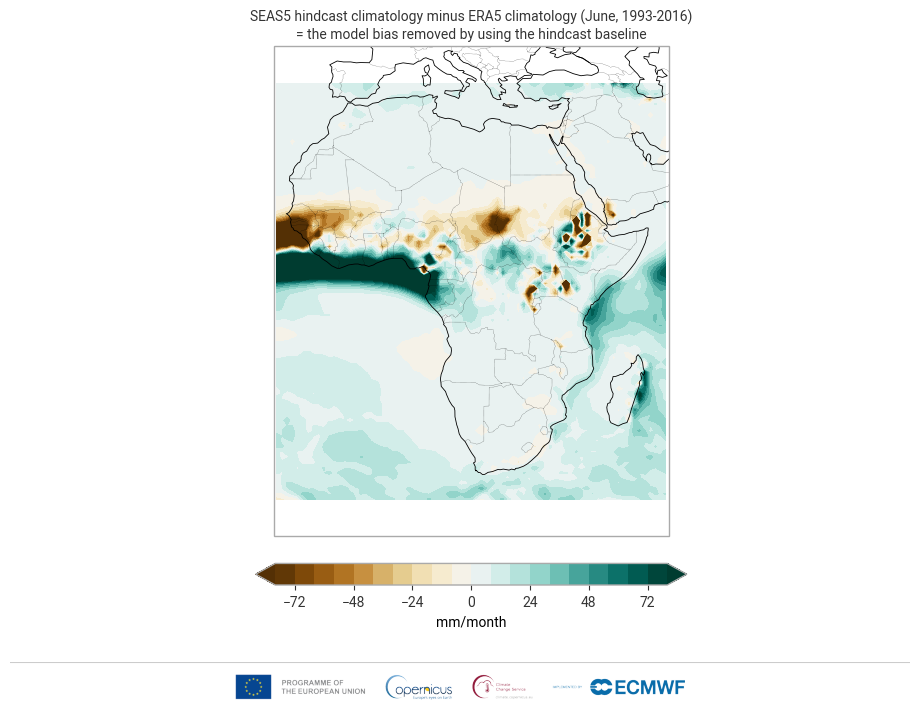

In [35]:
# ERA5 climatology for the first valid month, regridded to the SEAS5 grid
e5_times = pd.DatetimeIndex(e5.time.values)
m1 = valid_times[0].month
d1 = float(days_in_month.isel({lead_dim: 0}))
e5_clim_m1 = (e5.isel(time=(e5_times.month == m1)).mean('time') * d1 * 1000)
e5_clim_m1 = e5_clim_m1.interp(latitude=fc.latitude, longitude=fc.longitude)

bias = hc_clim.isel({lead_dim: 0}) - e5_clim_m1

fig, ax = plt.subplots(figsize=(9, 7), subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=':')
im = ax.contourf(bias.longitude, bias.latitude, bias,
                 levels=np.linspace(-80, 80, 21), cmap='BrBG',
                 transform=ccrs.PlateCarree(), extend='both')
plt.colorbar(im, ax=ax, label='mm/month', orientation='horizontal', pad=0.05, fraction=0.04)
ax.set_extent([-20, 55, -40, 40])
ax.set_title(f'SEAS5 hindcast climatology minus ERA5 climatology ({month_names[0]}, 1993-2016)\n'
             f'= the model bias removed by using the hindcast baseline', fontsize=10)
save_with_attribution(fig, FIG_DIR / '09_seas5_vs_era5_bias.png', dpi=150)
plt.show()


## 6) Regional Signal: All Lead Months

Area-weighted (cos latitude) ensemble mean anomaly per SEWA region x lead month.


In [36]:
# Vectorised: region_mean keeps the lead dimension, one call per region
print('SEAS5 El Nino Signal by Region and Lead Month')
print('=' * 80)
print(f"{'Region':<28}" + ''.join(f'  {m[:3]:>7}' for m in month_names))
print('-' * 80)

regional_anom = {}
for rname, reg in REGIONS.items():
    vals = region_mean(anom_mean, reg).values   # (n_leads,)
    regional_anom[rname] = vals
    marks = ['v' if v < -15 else ('^' if v > 15 else '.') for v in vals]
    print(f'{rname:<28}' + ''.join(f'  {v:>+5.0f}{s}' for v, s in zip(vals, marks)))

print()
print('Values = ensemble mean anomaly vs SEAS5 hindcast climatology 1993-2016 (mm/month)')
print('v  < -15 mm drier    ^  > +15 mm wetter    .  near-normal')
print('Note: ensemble mean only; see Sections 10-12 for confidence/spread')


SEAS5 El Nino Signal by Region and Lead Month
Region                            Jun      Jul      Aug      Sep      Oct      Nov
--------------------------------------------------------------------------------
Western Africa (AGRHYMET)        +1.     +8.     -2.     -8.    +11.     +4.
Central Africa (CAPC-AC)         +3.    +10.     +2.     -7.    +17^    +19^
Eastern Africa (ICPAC)          -18v    -12.    -15v     -0.    +62^    +49^
Southern Africa (SADC-CSC)       +6.     +2.     -0.     +0.     +2.     +3.

Values = ensemble mean anomaly vs SEAS5 hindcast climatology 1993-2016 (mm/month)
v  < -15 mm drier    ^  > +15 mm wetter    .  near-normal
Note: ensemble mean only; see Sections 10-12 for confidence/spread


## 7) Maps: Seasonal Precipitation Anomaly

Ensemble mean anomaly for the first and fourth lead months.

*How to read: red = drier than the model's own 1993-2016 normal for that calendar month, blue = wetter. Ensemble mean only: consult Sections 10-12 before treating any feature as confident.*


Saved: /Users/valtze/ecmwf-open-data-guide/figures/09_elnino_seasonal_outlook.png


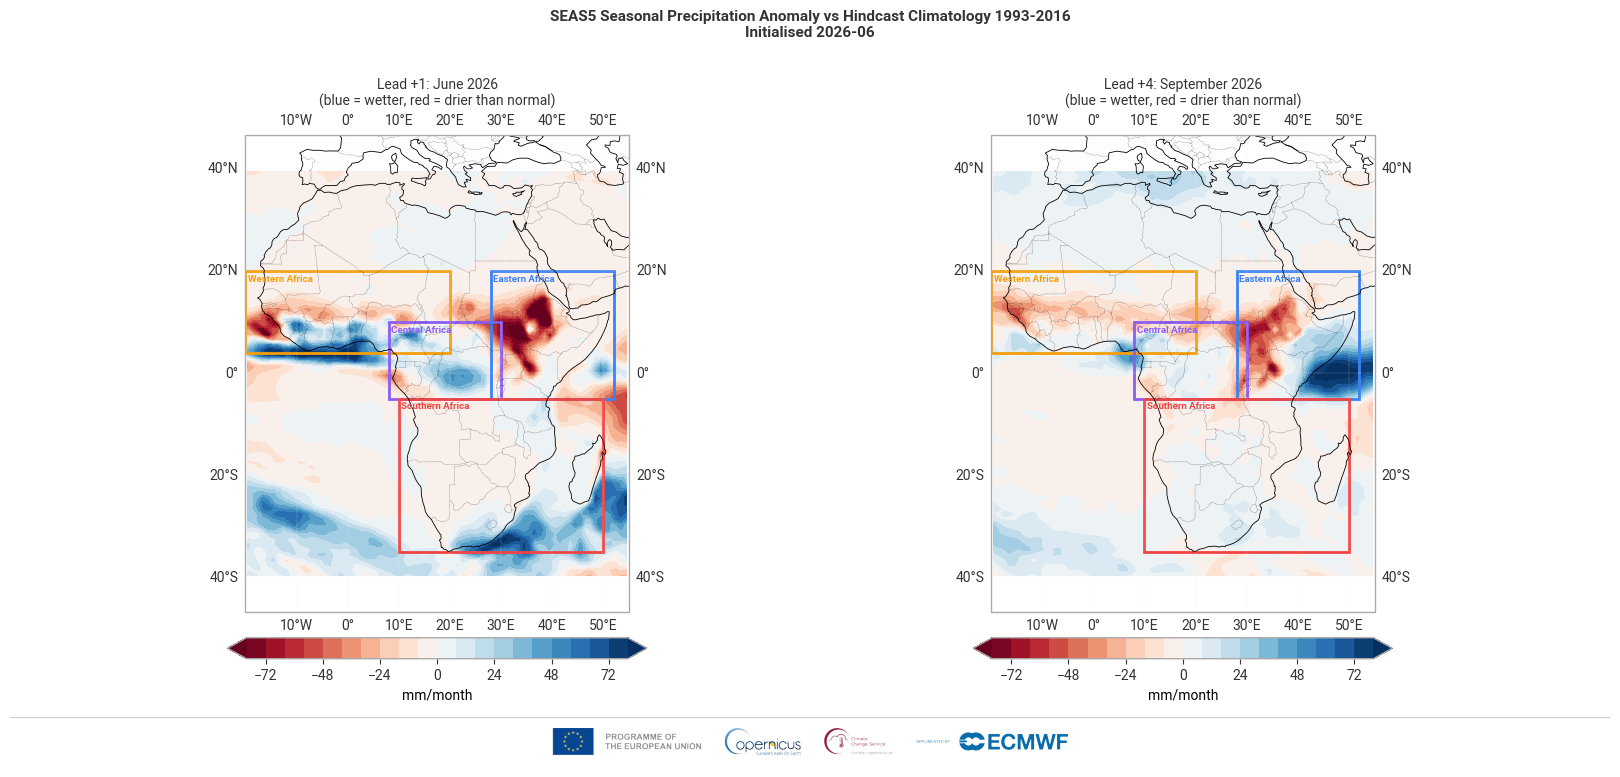

In [37]:
def plot_anomaly_map(ax, anom2d, title, vmin=-80, vmax=80):
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='#F5F5F5', alpha=0.2)
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    im = ax.contourf(anom2d.longitude, anom2d.latitude, anom2d,
                     levels=np.linspace(vmin, vmax, 21), cmap='RdBu', norm=norm,
                     transform=ccrs.PlateCarree(), extend='both')
    plt.colorbar(im, ax=ax, label='mm/month', orientation='horizontal',
                 pad=0.05, fraction=0.04)
    for rname, reg in REGIONS.items():
        ax.add_patch(Rectangle(
            (reg['lon'][0], reg['lat'][0]),
            reg['lon'][1] - reg['lon'][0], reg['lat'][1] - reg['lat'][0],
            linewidth=2, edgecolor=reg['color'], facecolor='none',
            transform=ccrs.PlateCarree()))
        ax.text(reg['lon'][0] + 0.5, reg['lat'][1] - 2, rname.split('(')[0].strip(),
                transform=ccrs.PlateCarree(), fontsize=7,
                color=reg['color'], fontweight='bold')
    ax.set_extent([-20, 55, -40, 40])
    ax.set_title(title, fontsize=10)
    return im

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
    subplot_kw={'projection': ccrs.PlateCarree()})
fig.suptitle(
    f'SEAS5 Seasonal Precipitation Anomaly vs Hindcast Climatology 1993-2016\n'
    f'Initialised {FCST_YEAR}-{FCST_MONTH}',
    fontsize=11, fontweight='bold', y=1.01)

for ax, i in zip(axes, [0, 3]):
    plot_anomaly_map(ax, anom_mean.isel({lead_dim: i}),
        f'Lead +{LEADS[i]}: {month_names[i]} {valid_times[i].year}\n'
        f'(blue = wetter, red = drier than normal)')

plt.tight_layout()
save_with_attribution(fig, FIG_DIR / '09_elnino_seasonal_outlook.png', dpi=150)
plt.show()


## 8) Multi-Lead Timeline: Evolving El Nino Signal

Six-panel figure showing the ensemble mean anomaly across all lead months.

*How to read: same colour convention as Section 7, one panel per verifying month. Watch how features strengthen, fade, or flip sign with lead time.*


Saved: /Users/valtze/ecmwf-open-data-guide/figures/09_elnino_full_timeline.png


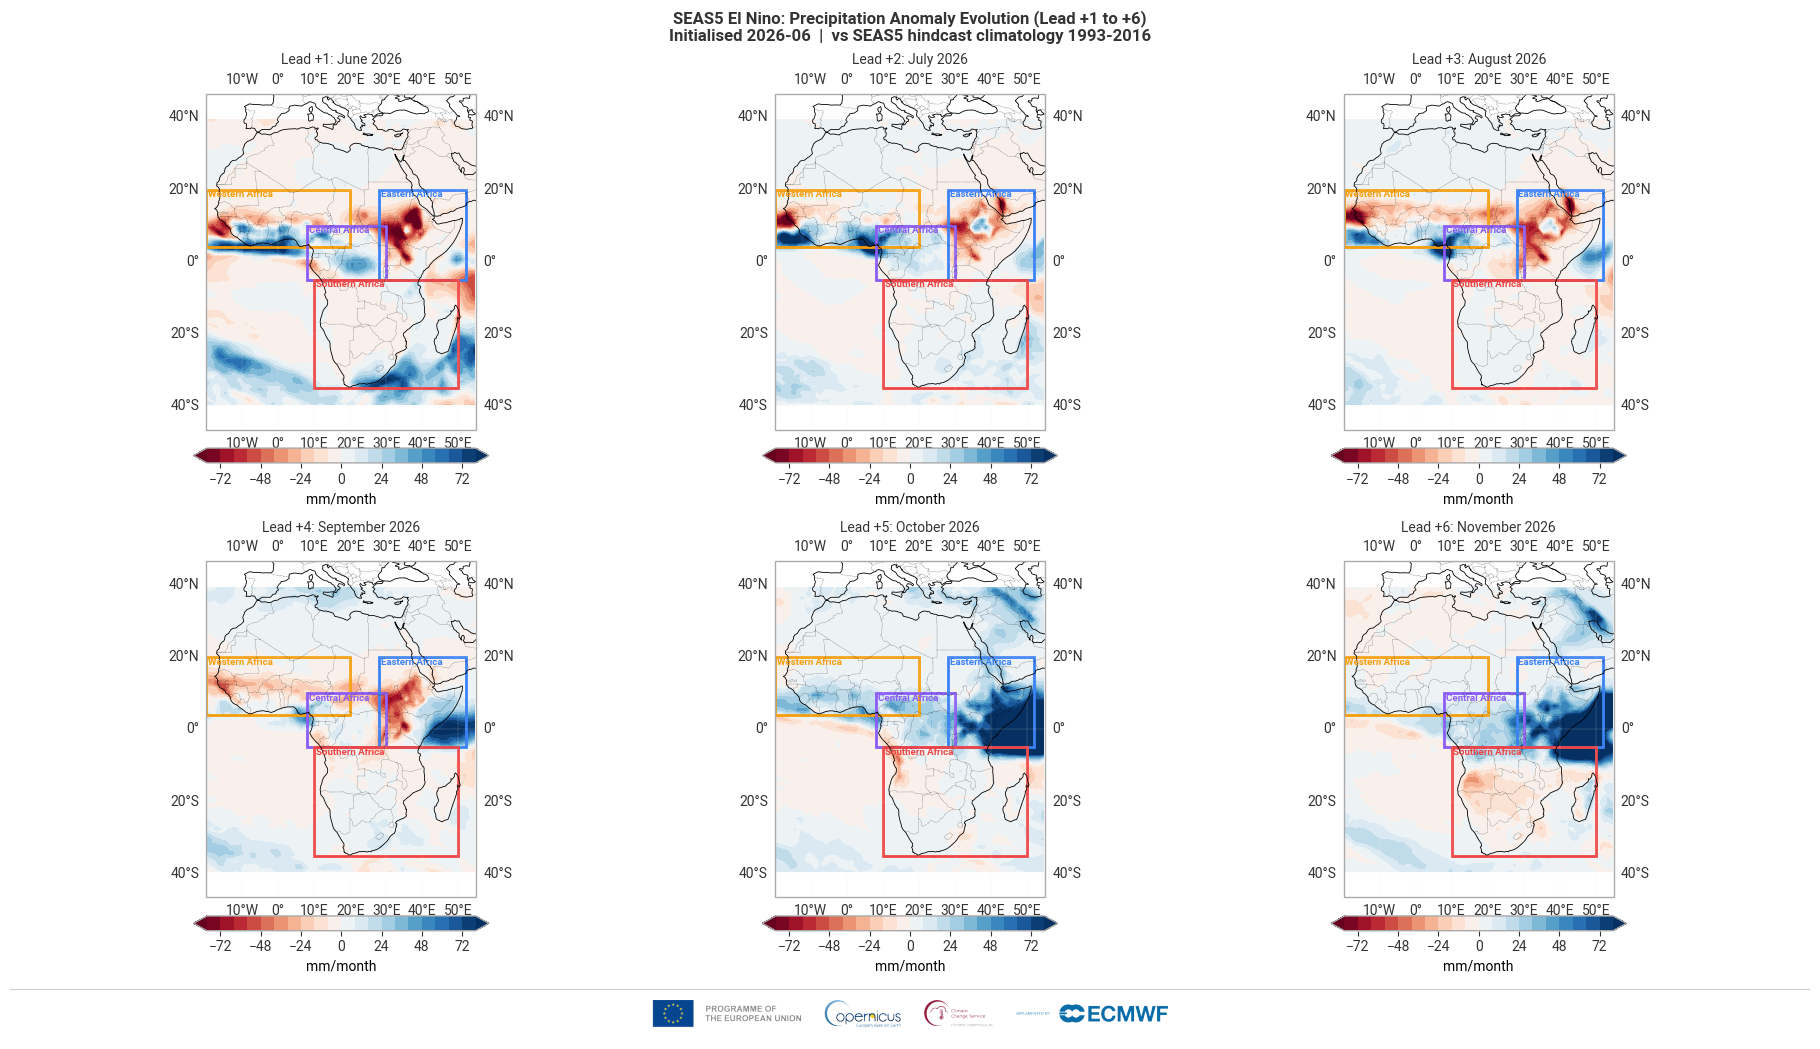

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10),
    subplot_kw={'projection': ccrs.PlateCarree()})
fig.suptitle(
    f'SEAS5 El Nino: Precipitation Anomaly Evolution (Lead +1 to +6)\n'
    f'Initialised {FCST_YEAR}-{FCST_MONTH}  |  vs SEAS5 hindcast climatology 1993-2016',
    fontsize=12, fontweight='bold')

for ax, i in zip(axes.flatten(), range(n_leads)):
    plot_anomaly_map(ax, anom_mean.isel({lead_dim: i}),
        f'Lead +{LEADS[i]}: {month_names[i]} {valid_times[i].year}')

plt.tight_layout()
save_with_attribution(fig, FIG_DIR / '09_elnino_full_timeline.png', dpi=150)
plt.show()


## 9) The Anticipatory Action Chain

For early warning systems, seasonal forecasts are the **trigger layer**: they initiate preparedness actions months before an event:

```
SEAS5 (1-7 months ahead)
    → Is this a drought / flood season?
    → Pre-position resources, activate coordination mechanisms
    → Inform the Continental Preparedness Framework

S2S sub-seasonal (2-6 weeks ahead)
    → Which weeks are anomalous?
    → Activate national NMHS protocols, issue advisories

IFS / AIFS medium-range (0-15 days)
    → When exactly? How intense?
    → Issue official warnings, trigger early action

AMSAF nowcasting (0-6 hours)
    → Where right now?
    → Emergency response, evacuations
```

**SEWA context:** The IbF pilot grants (Call opens June 2026) will develop tools
that operationalise exactly this seasonal signal into actionable early warnings
at national NMHS level: using the same SEAS5 data shown here.

**Data access: all free today:**
- SEAS5 + ERA5: [cds.climate.copernicus.eu](https://cds.climate.copernicus.eu)
- IFS/AIFS open data: [data.ecmwf.int](https://data.ecmwf.int): no account needed


## 10) Ensemble Spread: Probability of Below-Normal Precipitation

**What this adds:** The ensemble mean (Sections 6-8) shows *where* the signal points
but not *how confident* the forecast is. A -30 mm/month mean anomaly means something
very different if 50 of 51 members agree vs if only 26 do.

**Method:** For each grid point and each lead month, count the fraction of the 51
ensemble members showing anomaly below -15 mm/month (meaningful drought threshold).
Values above 60% indicate a robust signal; values near 33% indicate no skill above
the climatological base rate.

> **Interpretation guide:**
> - **> 60%** strong consensus, suitable for preparedness trigger
> - **40-60%** moderate signal, monitor closely
> - **< 40%** near-climatological uncertainty, low confidence

*How to read: shading = share of the 51 members below the -15 mm/month threshold; the black contour marks 60% consensus. Inside the contour the dry signal is robust across the ensemble, not an artifact of a few members.*


Saved: /Users/valtze/ecmwf-open-data-guide/figures/09_elnino_prob_drought.png


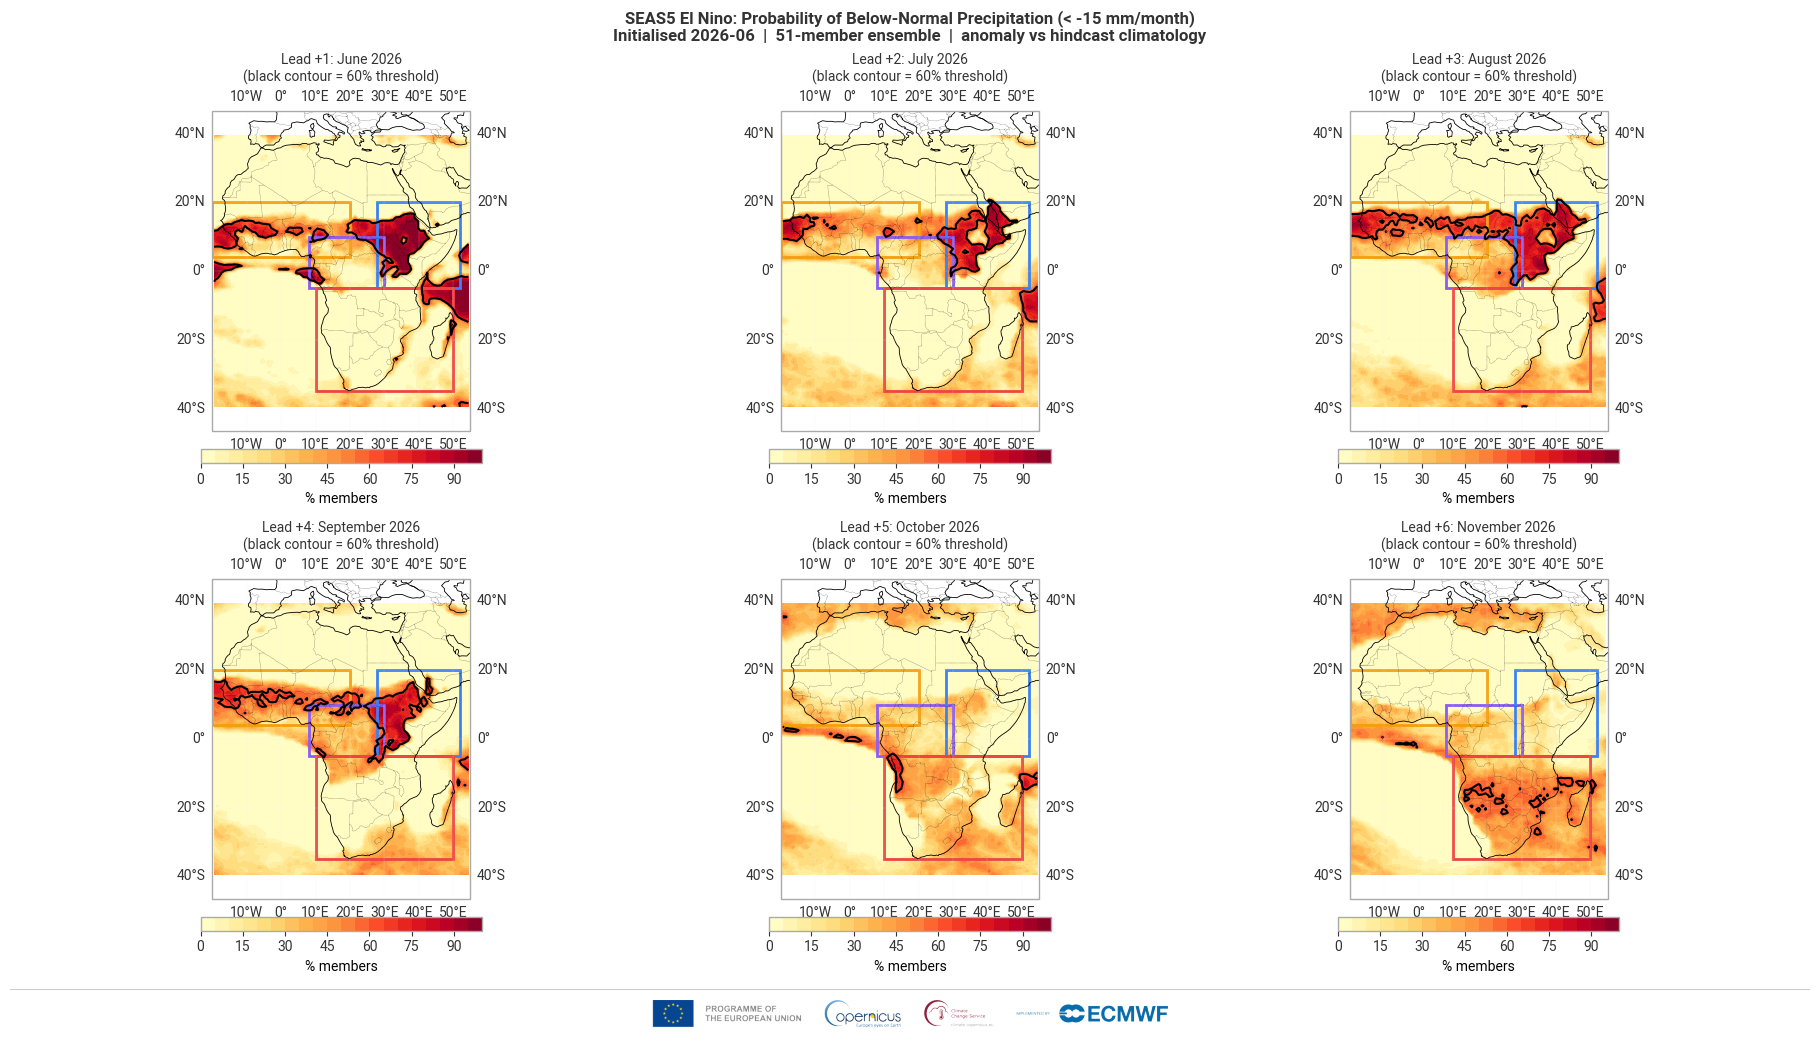

In [39]:
DROUGHT_THRESHOLD = -15  # mm/month

# Vectorised over all leads at once: (lead, lat, lon) in one line
prob_drought = (anom_members < DROUGHT_THRESHOLD).mean(member_dim) * 100

fig, axes = plt.subplots(2, 3, figsize=(18, 10),
    subplot_kw={'projection': ccrs.PlateCarree()})
fig.suptitle(
    f'SEAS5 El Nino: Probability of Below-Normal Precipitation (< -15 mm/month)\n'
    f'Initialised {FCST_YEAR}-{FCST_MONTH}  |  51-member ensemble  |  '
    f'anomaly vs hindcast climatology',
    fontsize=12, fontweight='bold')

for ax, i in zip(axes.flatten(), range(n_leads)):
    pd_i = prob_drought.isel({lead_dim: i})
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=':')
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
    im = ax.contourf(pd_i.longitude, pd_i.latitude, pd_i,
                     levels=np.linspace(0, 100, 21), cmap='YlOrRd',
                     transform=ccrs.PlateCarree())
    plt.colorbar(im, ax=ax, label='% members', orientation='horizontal',
                 pad=0.05, fraction=0.04)
    ax.contour(pd_i.longitude, pd_i.latitude, pd_i, levels=[60],
               colors='black', linewidths=1.5, transform=ccrs.PlateCarree())
    for rname, reg in REGIONS.items():
        ax.add_patch(Rectangle(
            (reg['lon'][0], reg['lat'][0]),
            reg['lon'][1] - reg['lon'][0], reg['lat'][1] - reg['lat'][0],
            linewidth=2, edgecolor=reg['color'], facecolor='none',
            transform=ccrs.PlateCarree()))
    ax.set_extent([-20, 55, -40, 40])
    ax.set_title(f'Lead +{LEADS[i]}: {month_names[i]} {valid_times[i].year}\n'
                 f'(black contour = 60% threshold)', fontsize=10)

plt.tight_layout()
save_with_attribution(fig, FIG_DIR / '09_elnino_prob_drought.png', dpi=150)
plt.show()


## 11) Tercile Probabilities by Region

**What this adds:** WMO standard seasonal forecast format. For each SEWA region and
lead month, the 51 forecast members are classified into:
- **Below normal** (BN): bottom tercile
- **Near normal** (NN): middle tercile
- **Above normal** (AN): top tercile

A climatological (no-skill) forecast gives 33/33/33%. Departure from this baseline
shows where the forecast has useful signal.

**How tercile boundaries are derived:** From the SEAS5 *hindcast* distribution for
each region x lead month: the 24 years x 25 members = 600 regional values, taking
the 33.3rd and 66.7th percentiles. Boundaries and forecast values come from the same
model world, so no bias leaks into the classification (this was the key correction
vs earlier versions of this notebook, which mixed ERA5 boundaries with SEAS5 values).

> **Dry-season caveat:** In months where a region's climatological rainfall is
> near zero (e.g. Southern Africa in June-August), tercile boundaries are only
> millimetres apart and the BN/NN/AN split is numerically unstable and
> operationally meaningless. Read tercile bars only for months inside the
> region's rainy season.

*How to read: each bar splits the 51 members into below/near/above normal; the dashed line is the 33% no-skill baseline. Signal = strong departure from 33/33/33, but only in months inside the region's rainy season (see caveat above).*


In [40]:
# Regional area-weighted values, vectorised over member/year/lead in one call each
tercile = {}   # tercile[region][lead_index] = dict(BN=, NN=, AN=)
for rname, reg in REGIONS.items():
    hc_reg = region_mean(hc_mm, reg)   # (member, year, lead)
    fc_reg = region_mean(fc_mm, reg)   # (member, lead)
    tercile[rname] = {}
    for i in range(n_leads):
        pool = hc_reg.isel({lead_dim: i}).values.ravel()      # 600 hindcast values
        t33, t67 = np.percentile(pool, [33.3, 66.7])
        vals = fc_reg.isel({lead_dim: i}).values              # 51 forecast values
        bn = float((vals < t33).mean() * 100)
        an = float((vals > t67).mean() * 100)
        tercile[rname][i] = {'BN': bn, 'NN': 100 - bn - an, 'AN': an}

print('Tercile probabilities (hindcast-based boundaries)')
print(f'\nSample: Southern Africa:')
for i in range(n_leads):
    t = tercile['Southern Africa (SADC-CSC)'][i]
    print(f'  Lead +{LEADS[i]} ({month_names[i][:3]}): '
          f'BN={t["BN"]:.0f}%  NN={t["NN"]:.0f}%  AN={t["AN"]:.0f}%')


Tercile probabilities (hindcast-based boundaries)

Sample: Southern Africa:
  Lead +1 (Jun): BN=0%  NN=18%  AN=82%
  Lead +2 (Jul): BN=16%  NN=29%  AN=55%
  Lead +3 (Aug): BN=33%  NN=35%  AN=31%
  Lead +4 (Sep): BN=33%  NN=31%  AN=35%
  Lead +5 (Oct): BN=20%  NN=29%  AN=51%
  Lead +6 (Nov): BN=25%  NN=37%  AN=37%


Saved: /Users/valtze/ecmwf-open-data-guide/figures/09_elnino_tercile_probs.png


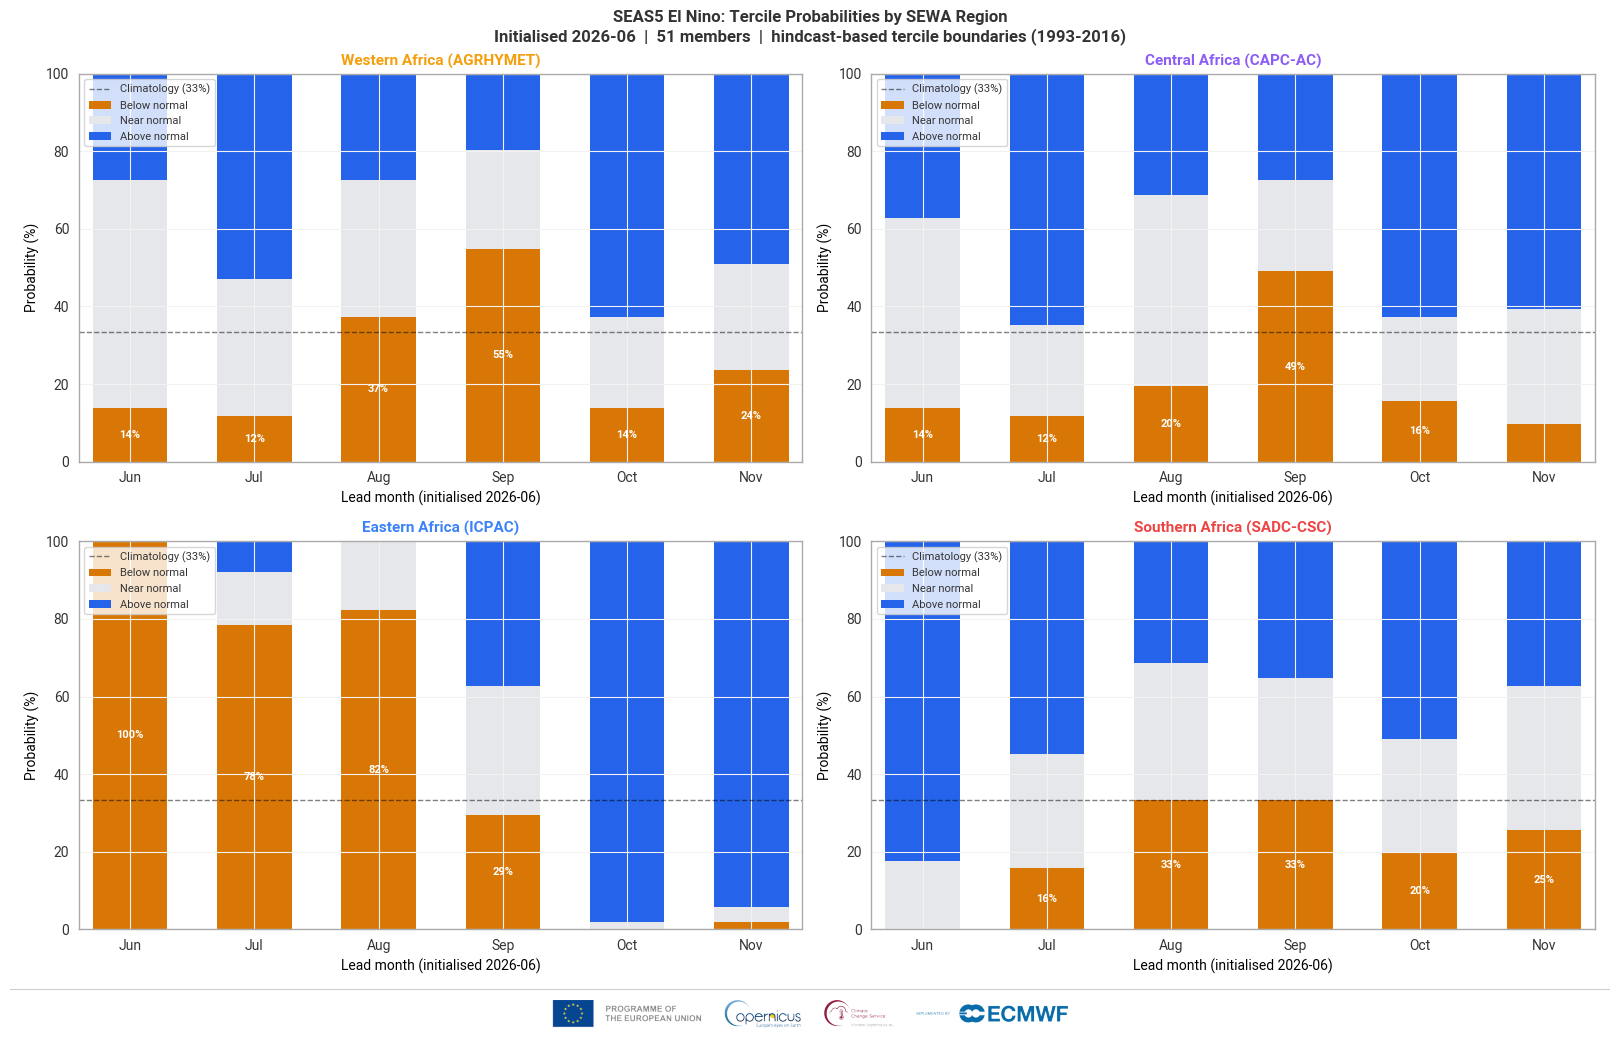

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
x = np.arange(n_leads)
mlabels = [m[:3] for m in month_names]
BN_COLOR, NN_COLOR, AN_COLOR = '#D97706', '#E5E7EB', '#2563EB'

for ax, (rname, reg) in zip(axes.flatten(), REGIONS.items()):
    bn = [tercile[rname][i]['BN'] for i in range(n_leads)]
    nn = [tercile[rname][i]['NN'] for i in range(n_leads)]
    an = [tercile[rname][i]['AN'] for i in range(n_leads)]
    ax.bar(x, bn, 0.6, label='Below normal', color=BN_COLOR)
    ax.bar(x, nn, 0.6, bottom=bn, label='Near normal', color=NN_COLOR)
    ax.bar(x, an, 0.6, bottom=[b + n for b, n in zip(bn, nn)],
           label='Above normal', color=AN_COLOR)
    ax.axhline(33.3, color='black', linewidth=1.0, linestyle='--',
               alpha=0.5, label='Climatology (33%)')
    ax.set_xticks(x); ax.set_xticklabels(mlabels)
    ax.set_ylim(0, 100); ax.set_ylabel('Probability (%)')
    ax.set_title(rname, color=reg['color'], fontweight='bold', fontsize=11)
    ax.legend(fontsize=8, loc='upper left')
    ax.set_xlabel(f'Lead month (initialised {FCST_YEAR}-{FCST_MONTH})')
    for i, v in enumerate(bn):
        if v > 10:
            ax.text(i, v / 2, f'{v:.0f}%', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')

fig.suptitle(
    f'SEAS5 El Nino: Tercile Probabilities by SEWA Region\n'
    f'Initialised {FCST_YEAR}-{FCST_MONTH}  |  51 members  |  '
    f'hindcast-based tercile boundaries (1993-2016)',
    fontsize=12, fontweight='bold')
plt.tight_layout()
save_with_attribution(fig, FIG_DIR / '09_elnino_tercile_probs.png', dpi=150)
plt.show()


## 12) Ensemble Plume: Member Agreement Over Time

**What this adds:** All 51 members as individual lines (spaghetti), with the ensemble
mean overlaid. The clearest way to see:

- **Tight cluster** -> high confidence, strong signal
- **Wide spread** -> model uncertainty is large, signal weaker
- **Bimodal distribution** -> some members in the opposite regime (inspect carefully)

Each panel is one SEWA region; y-axis is the area-weighted precipitation anomaly.

*How to read: each thin line is one member's regional-mean anomaly trajectory; shading is the interquartile range. A tight bundle means high confidence; a wide fan means the mean line alone would overstate certainty.*


Saved: /Users/valtze/ecmwf-open-data-guide/figures/09_elnino_ensemble_plume.png


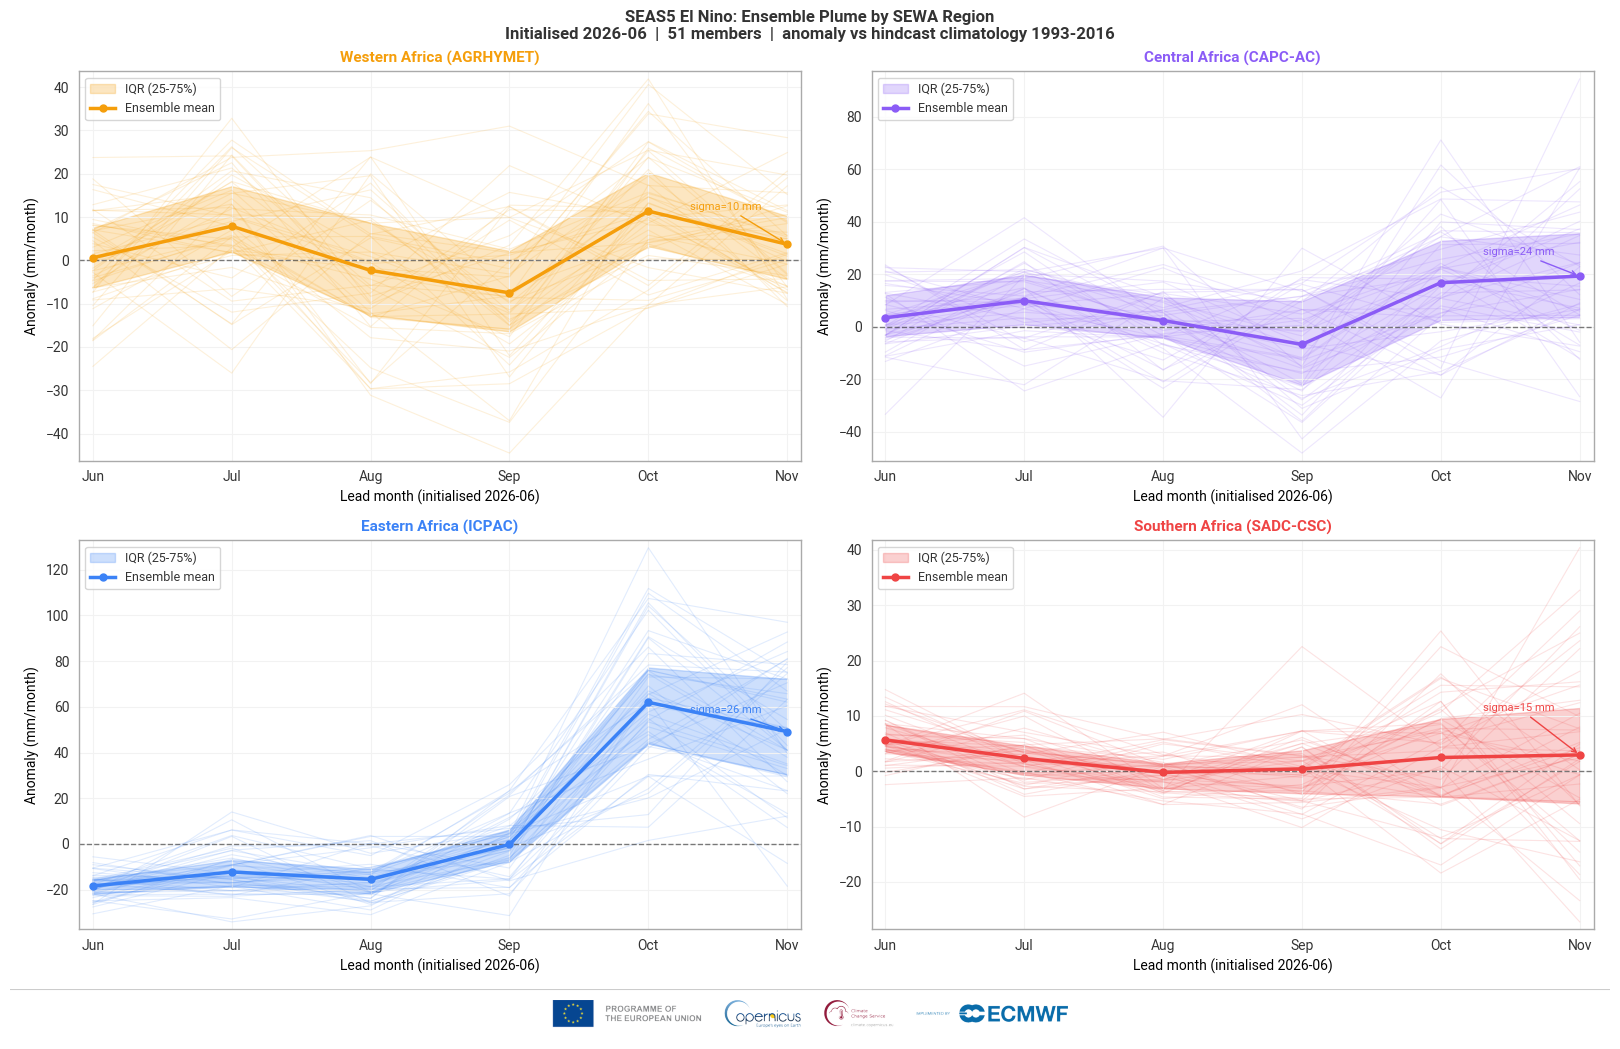

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
x = np.arange(n_leads)
mlabels = [m[:3] for m in month_names]

for ax, (rname, reg) in zip(axes.flatten(), REGIONS.items()):
    # One vectorised call: (member, lead) matrix of area-weighted anomalies
    ma = region_mean(anom_members, reg).transpose(member_dim, lead_dim).values
    ens_mean = ma.mean(axis=0)

    for row in ma:
        ax.plot(x, row, color=reg['color'], alpha=0.15, linewidth=0.8)
    q25, q75 = np.percentile(ma, [25, 75], axis=0)
    ax.fill_between(x, q25, q75, color=reg['color'], alpha=0.25, label='IQR (25-75%)')
    ax.plot(x, ens_mean, color=reg['color'], linewidth=2.5,
            marker='o', markersize=5, label='Ensemble mean', zorder=5)
    ax.axhline(0, color='black', linewidth=1.0, linestyle='--', alpha=0.5)

    ax.set_xticks(x); ax.set_xticklabels(mlabels)
    ax.set_ylabel('Anomaly (mm/month)')
    ax.set_title(rname, color=reg['color'], fontweight='bold', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlabel(f'Lead month (initialised {FCST_YEAR}-{FCST_MONTH})')
    ax.annotate(f'sigma={ma[:, -1].std():.0f} mm',
                xy=(x[-1], ens_mean[-1]), xytext=(x[-1] - 0.7, ens_mean[-1] + 8),
                fontsize=8, color=reg['color'],
                arrowprops=dict(arrowstyle='->', color=reg['color'], lw=1))

fig.suptitle(
    f'SEAS5 El Nino: Ensemble Plume by SEWA Region\n'
    f'Initialised {FCST_YEAR}-{FCST_MONTH}  |  51 members  |  '
    f'anomaly vs hindcast climatology 1993-2016',
    fontsize=12, fontweight='bold')
plt.tight_layout()
save_with_attribution(fig, FIG_DIR / '09_elnino_ensemble_plume.png', dpi=150)
plt.show()


## 13) Confidence Summary Table

Combines the ensemble mean signal with spread information into a single
decision-support table, intended for the preparedness framework briefing.

**Confidence scoring:**
- Signal strength: |mean anomaly| relative to threshold (15 mm/month)
- Spread: standard deviation of member area-weighted averages
- Signal-to-noise ratio (SNR): |mean| / std; higher = more confident

> **Preparedness note:** Cells marked HIGH with SNR > 1.5 are the most
> suitable candidates for defining anticipatory action triggers from SEAS5.

*How to read: SNR compares signal strength to ensemble spread. Only MODERATE/HIGH rows are candidates for operational messaging; cross-check them against the maps, since box averages can hide sub-regional structure.*


In [43]:
print('SEAS5 El Nino: Signal + Confidence Summary')
print('=' * 100)
print(f"{'Region':<28}  {'Lead':<5}  {'Month':<10}  {'Mean (mm)':<10}  "
      f"{'Spread':<7}  {'SNR':<5}  {'Signal':<8}  {'Confidence'}")
print('-' * 100)

for rname, reg in REGIONS.items():
    ma = region_mean(anom_members, reg).transpose(member_dim, lead_dim).values
    for i in range(n_leads):
        mean_anom, spread = ma[:, i].mean(), ma[:, i].std()
        snr = abs(mean_anom) / spread if spread > 0 else 0
        signal = 'DRIER' if mean_anom < -15 else ('WETTER' if mean_anom > 15 else 'NEUTRAL')
        conf = 'HIGH' if snr > 1.5 else ('MODERATE' if snr > 0.8 else 'LOW')
        print(f'{rname:<28}  +{LEADS[i]:<4}  {month_names[i]:<10}  {mean_anom:>+8.1f}  '
              f'{spread:>7.1f}  {snr:>5.2f}  {signal:<8}  {conf}')
    print()

print('SNR = |mean anomaly| / ensemble std dev')
print('HIGH confidence = SNR > 1.5  |  MODERATE = 0.8-1.5  |  LOW = < 0.8')


SEAS5 El Nino: Signal + Confidence Summary
Region                        Lead   Month       Mean (mm)   Spread   SNR    Signal    Confidence
----------------------------------------------------------------------------------------------------
Western Africa (AGRHYMET)     +1     June            +0.6     10.3   0.06  NEUTRAL   LOW
Western Africa (AGRHYMET)     +2     July            +7.9     12.8   0.61  NEUTRAL   LOW
Western Africa (AGRHYMET)     +3     August          -2.3     14.8   0.16  NEUTRAL   LOW
Western Africa (AGRHYMET)     +4     September       -7.5     15.4   0.49  NEUTRAL   LOW
Western Africa (AGRHYMET)     +5     October        +11.4     13.7   0.83  NEUTRAL   MODERATE
Western Africa (AGRHYMET)     +6     November        +3.7      9.6   0.39  NEUTRAL   LOW

Central Africa (CAPC-AC)      +1     June            +3.4     11.3   0.30  NEUTRAL   LOW
Central Africa (CAPC-AC)      +2     July            +9.9     13.7   0.72  NEUTRAL   LOW
Central Africa (CAPC-AC)      +3     Aug

---

## Note for internal reviewers (draft status, July 2026)

- **Initialisation shown is June 2026** (verifying Jun-Nov): new SEAS5 runs reach
  the CDS around the 13th of each month, so before that date the notebook falls
  back to the previous month's initialisation automatically (see Section 2).
  A rerun after mid-July will switch everything to the July initialisation.
- Interpretation of specific runs is deliberately **not** hard-coded here: derive
  messages from the confidence table (Section 13) cross-checked against the maps.
  From the June run, the robust features were the Eastern Africa dry-to-wet flip
  peaking in the Oct-Nov short rains, and a Sahel/Guinea-coast dipole that cancels
  in the Western Africa box average: a good example of why maps and regional means
  must be read together.
- Feedback particularly welcome on: region box definitions, the -15 mm/month
  drought threshold, and whether the bias-illustration section (Section 5) earns
  its place for training audiences.

*Data: ECMWF SEAS5 (forecast and hindcast) and ERA5, all via Copernicus CDS*
*Contact: sewa@ecmwf.int - support.ecmwf.int*
